This Jupyter notebook describes how to use pyBIS to implement the example from the tutorial “Uploading Data to the openBIS Data Store – Lab Notebook.”
https://bamresearch.github.io/openBIS-data-store-tutorials/eln/tutorial-eln.html#step-2


Important Libraries

In [ ]:
%pip install pybis
%pip install requests
%pip install zipfile

In [ ]:
from helper import *#helper functions for this notebook

### To log in using a session token,

1. Log in to the Bam Data Store website 
2. Go to the Tools tab on the top left
3. Select User Profile from the list of options provided
4. Copy the OpenBIS session token and use it in the next cell.

In [ ]:
from pybis import Openbis
o = Openbis("https://playground.datastore.bam.de/")

o.set_token("user_token_here")

Download Datasets for future use.

In [ ]:
import os
import requests

urls =  ["https://bamresearch.github.io/openBIS-data-store-tutorials/eln/datasets/Parameter1_Macroscopic.zip", 
         "https://bamresearch.github.io/openBIS-data-store-tutorials/eln/datasets/datasets.zip"]

folder = "Data"
filenames = ["Parameter1_Macroscopic.zip", "datasets.zip"]

os.makedirs(folder, exist_ok=True)

for i in range(2):
    filepath = os.path.join(folder, filenames[i])
    response = requests.get(urls[i], stream=True)
    response.raise_for_status()

    with open(filepath, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print(f"Saved file to {filepath}")

### The next cell is used to extract the zip file called datasets.zip

In [ ]:
import zipfile

zip_path = "Data/datasets.zip"
extract_dir = "Data"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

print(f"Extracted {zip_path} to {extract_dir}")

os.remove("Data/datasets.zip")#removes the zipped version of the file which we do not need anymore

In [ ]:
# print(o.get_spaces())#please uncomment this line and execute it to see all the spaces and find the code for yours in the table displayed

myspace = o.get_space('your_space_code')#input your space's code here to save it in the myspace variable

In [ ]:
myspace.attrs.all()#run to see your space's info.

### Step 1: Register a Project called 'Material Synthesis'.


In [ ]:
myspace.get_projects()#to see current projects in the space

In [ ]:
project = myspace.new_project(
    code        = 'Material_Synthesis',#This is the name of the project
    description = 'This tutorial project demonstrates a simplified workflow for the synthesis and characterization of a material within openBIS. The experimental descriptions, metadata, and datasets were generated using AI and represent synthetic example data created solely for training and demonstration purposes. Although the content has been reviewed for consistency and usability within the tutorial, it has not been validated for scientific accuracy and should not be considered scientifically reliable or reproducible.'
)
project#has not been registered yet, need to call project.save() to save it to the openBIS server

In [ ]:
project.save()#this will save the project into the space you set in myspace

In [ ]:
myspace.get_projects()#as you can see, a new project has been registered

In [ ]:
#in case you have already created the project and want to save it into a variable because you have closed the notebook and reopened it, 
# you can use this line to get the project we just created and save it in the variable project

# project= myspace.get_project('Material_Synthesis')

### Step 2: Register Collections of Experimental Steps

We will be creating and registering a collection called 'Synthesis' under the project that you just registered.

In [ ]:
project.get_collections()#As you have not yet registered any collections yet, this will return an empty list

In [ ]:
col = o.new_collection(
    code = auto_generated_code(project), #the 'auto_generated_code' function will generate a new code for the collection based on the number of collections already in the project
    type='Collection',#this specifies that  the new entity is of the type 'collection'.
    project= project.identifier,#project.identifier is the unique identifier for the project called material synthesis that was created in step 1 and in which this new collection will be registered. 
    props = {'$name': 'Synthesis'}#Enter the name of the Collection here.
)
col

In [ ]:
col.save()#to save the collection in the project you created

In [ ]:
project.get_collections()#You will see the collection you just saved.

# The function 'search_collection': 
- Searches collections by a given keyword (for example: 'param' would return Parameter 1 and Parameter 2)
- returns indices and collection names

Use the keyword 'all' to return all the collections in the project

### Note: In case there is a change of the session token, the search_collection function will not work properly unless you load myspace, and project variables again into the notebook



In [ ]:
search_collection(project,'all')#valid characters are a-z, space, A-Z, -, _
#We will be using the index displayed in the output of this cell in the next cell

In [ ]:
col = project.get_collections()[0]#you can select one collection from multiple collections by using the index. For example, for Collection Synthesis with index [0].

col.props.all()#to see the properties for the collection

### Registering additional collections

We will now create additional collections by reusing the same knowledge we applied in step 2.

The names for the collections are: Treatment non-destructive, Structure_TEM, Parameter 1, and Parameter 2

In [ ]:
collection_names = ["Treatment non-destructive","Structure_TEM","Parameter 1","Parameter 2"]#names of the collections to register

for name in collection_names:
    collection = o.new_collection(
        code=auto_generated_code(project),#code is autogenerated for each collection
        type='Collection',
        project= project.identifier,
        props = {'$name': name}
    )
    collection.save()
    print(f"Created collection: {name}")

project.get_collections()

### Step 3: Register Experimental Steps

The image displays steps described in the ELN Tutorial that we will be doing with pybis


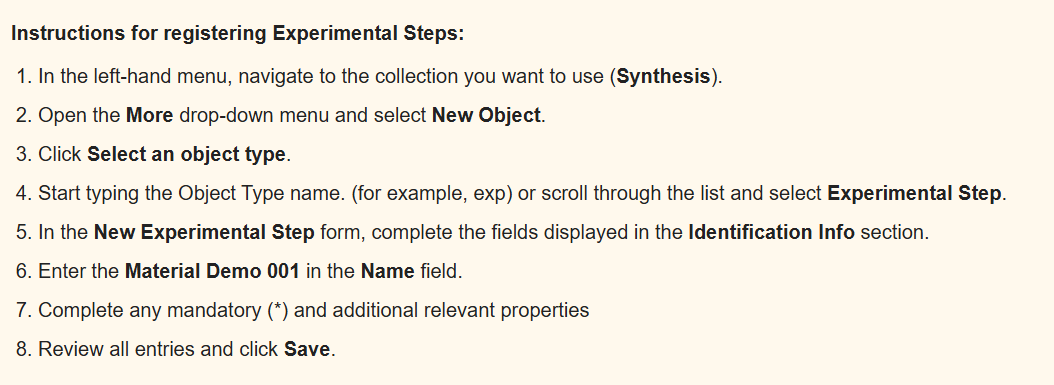

Note: Experimental Steps are represented as objects in openBIS. 
To register objects in pyBIS, openBIS refers to them as samples.

In [ ]:
search_collection(project,'all')
#Use this function to clarify the index of your collection(s):
#search_collection(project,'all') to display all collection within the project

#col = project.get_collections()[0]#use this line to select a specific collection by its index, for example, to select the first collection, use index [0].

In [ ]:
project.get_collections()[0].props.all()
#At the time this notebook was created, 'Synthesis' had index [0], but this may change for you.
#Please use the index displayed for 'Synthesis' in the previous cell output.

In [ ]:
col = project.get_collections()[0]#To save the collection 'Synthesis' in the variable col for further use.
col.props()#this should also result in synthesis and not some other collection

In [ ]:
sample = o.new_sample(#To register an Experimental Step within the collection 'Synthesis', we create a new sample/Object of type 'EXPERIMENTAL_STEP' with the specified properties.
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      = {"$name": "Material Demo 001", "experimental_step.experimental_description": "To synthesize a demo material"}
)
sample

In [ ]:
sample.save()#to save it into the data store

### Step 4 : Register Experimental Steps using Templates
Experimental Steps may require extensive metadata to fully describe the datasets generated. To standardize this information and simplify the registration of similar Experimental Steps, reusable templates can be created and shared within a division. Templates are particurly useful for repetitive workflows in which experimental conditions remain the same or require minor modifications. They help ensure consistency, reduce manual data entry, and improve the efficiency of experimental documentation.


We will now register an Experimental Step using a previously defined Template that allows reusability and fills out a lot of metadata fields for the experiment.

In [ ]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Material Synthesis']#templates are defined in the helper.py file
)#To access the the definition of templates, you can right-click on 'templates' in the above line and select 'Go to Definition' to go to the dictionary where templates are defined
template_sample

In [ ]:
template_sample.save()#save this into the data store

Upon executing the next cell, you should see in the following output cells and in the openBIS instance (GUI-graphical user interface) that there are now two Experimental Steps registered under 'Synthesis':
- Material Demo 001 (created in step 3)
- Material Synthesis (created in step 4)

In [ ]:
col.get_objects()#To retrieve and display the objects within the collection.

### Step 5: Edit Collections and Objects (Experimental Steps)


To learn how to edit collections, we will be renaming the collection 'Structure TEM' to 'Parameter 2 Analysis' 

Since there are multiple collections in our Project, we will use the `search_collection()` function to facilitate the work with collections.

In [ ]:
search_collection(project,'all')

In [ ]:
exp_to_rename = project.get_experiments()[2]#To rename the Experimental Step 'Structure_TEM', we save it in the variable exp_to_rename. 
#Note that the index may vary for you, so please refer to the output of the previous cell to find the correct index.

In [ ]:
exp_to_rename.props.all()#To view the properties of the Experimental Step 'Structure_TEM', we call the props.all() method on the exp_to_rename variable. 
#This allows us to identify the field we want to edit, which is the $name property.

In [ ]:
exp_to_rename.props['$name'] = 'Parameter 2 Analysis'#To set the '$name' property of the exp_to_rename variable to 'Parameter 2 Analysis', which is the new name we want to assign to the Experimental Step.

In [ ]:
exp_to_rename.props.all()#run this to check if the change is applied locally

In [ ]:
exp_to_rename.save()#To save the changes made to the exp_to_rename variable, we call the save() method. This will update the properties of the Experimental Step in the data store.

### Deletion of objects

To learn how to delete objects, we will delete the object called 'Material Demo 001'

In [ ]:
#Material Demo 001 is an experiment under the collection 'Synthesis', that is why we need to first search for the index of 'Synthesis'
search_collection(project,'synthesis')#this is another way to use the search function

In [ ]:
#To save the collection 'Synthesis' in the variable col for further use. Please check the index of 'Synthesis' in the previous cell output, as it may vary for you.
col = project.get_collections()[0]
col.props.all()

In [ ]:
col.get_samples()#To retrieve and display the samples/objects within the collection 'Synthesis'. This will show the two experiments currently registered in the collection.

In [ ]:
#To avoid confusion in identifying the experiments from the previous cell's output, we print their properties to ensure we select the correct experiment.
for x in col.get_samples():
    print(x.props.all())

In [ ]:
sample_to_be_deleted = col.get_samples()[1]#To select the sample/object to be deleted, we save it in the variable sample_to_be_deleted. Please check the output of the previous cell to find the correct index for 'Material Demo 001' for your case.
sample_to_be_deleted.delete('Add reason here for deletion')

In [ ]:
col.get_samples()#To retrieve and display the samples/objects within the collection 'Synthesis' after deletion. This will show only one experiment remaining in the collection.

In [ ]:
col.get_samples()[0].props.all()#since we deleted Material Demo 001, the only experiment in this collection is Material Synthesis.

### Step 6: Register additional Experimental Steps using Templates

As described in Step 4, you will now create five additional Experimental Steps using predefined templates. These Experimental Steps will be required to complete the remaining exercises in this tutorial.

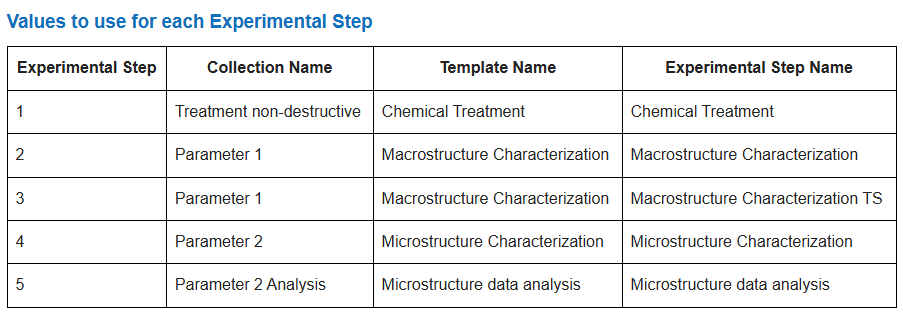

In [ ]:
search_collection(project,'all')#To retrieve and display all collections within the project. This allows us to identify the indices of the collections for further operations, such as adding Experimental Steps (samples) to them.

In [ ]:
col = project.get_experiments()[1]#To select the Experimental Step 'Treatment non-destructive', we save it in the variable col. Please check the output of the previous cell to find the correct index for your case.
col.props.all()

In [ ]:
#To add an experiment using the 'Chemical Treatment' template under the collection 'Treatment non-destructive', we create a new sample/Object of type 'EXPERIMENTAL_STEP' with the specified properties.
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Chemical Treatment']
)
template_sample.save()

In [ ]:
search_collection(project,'parameter 1')#To retrieve and display the collections within the project that match the search term 'parameter 1'. 

In [ ]:
col = project.get_experiments()[3]#To select the Experimental Step 'Parameter 1', we save it in the variable col. Please check the output of the previous cell to find the correct index for your case.
col.props.all()

In [ ]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Macrostructure Characterization']
)
template_sample.save()

In [ ]:
#To add another experiment using the 'Macrostructure Characterization TS' template under the collection 'Parameter 1', we create a new sample/Object of type 'EXPERIMENTAL_STEP' with the specified properties.
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Macrostructure Characterization TS']
)
template_sample.save()

In [ ]:
search_collection(project,'parameter 2')

In [ ]:
#To select the Experimental Step 'Parameter 2', we save it in the variable col. Please check the output of the previous cell to find the correct index for your case.
col = project.get_experiments()[4]
col.props.all()

In [ ]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Microstructure Characterization']
)
template_sample.save()

In [ ]:
search_collection(project,'analysis')

In [ ]:
#To select the Experimental Step 'Parameter 2 Analysis', we save it in the variable col. Please check the output of the previous cell to find the correct index for your case.
col = project.get_experiments()[2]
col.props.all()

In [ ]:
template_sample = o.new_sample(
    type       = 'EXPERIMENTAL_STEP',
    collection =  col,
    props      =  templates['Microstructure data analysis']
)
template_sample.save()

### Step 7: Upload Data

The Data Store recommends to attach datasets directly to Experimental Steps that describe how the data was generated. In openBIS, uploaded files are stored as Datasets. Because openBIS is format-agnostic, datasets can contain files of any type or format.

You will now upload a dataset (Parameter1_Macroscopic.zip) of type Raw Data to the Experimental Step called 'Macrostructure Characterization' organized within the collection 'Parameter 1'. You will also add some comments with the dataset.

You already downloaded the datasets required for this step at the beginning. They are saved in your local folder along with this Jupyter notebook.

In [ ]:
search_collection(project,'parameter 1')#To retrieve and display the collections within the project that match the search term 'parameter 1'.

In [ ]:
project.get_collections()[3].props.all()#To retrieve and display the properties of the collection 'Parameter 1'. Please check the output of the previous cell to find the correct index for your case.

In [ ]:
col = project.get_collections()[3]#To save the collection 'Parameter 1' in the variable col for further use. Please check the output of the previous cell to find the correct index for your case.

In [ ]:
#We need to find the index of the Experimental Step 'Macrostructure Characterization'.
for x in col.get_samples():
    print(x.props.all())

In [ ]:
sample = col.get_samples()[0]#We store Macrostructure Characterization in a variable

In [ ]:
#Run this if you do not know the code for Raw Data
o.get_dataset_types()#we need raw data which is on index [2]

In [ ]:
ds_new = o.new_dataset(
    type       = 'RAW_DATA',#the code from the table above if run
    sample     = sample.identifier,
    zipfile    = 'Data/Parameter1_Macroscopic.zip',#this is the dataset we downloaded and extracted at the start of the notebook
    props      = {'$name': 'Parameter 1 raw' ,'notes' : 'Synthetic example images for demo purpose.' }#We give it a name and some comments
)
ds_new.save()

### Exercise: Uploading data to the ELN preview

We will now add an image dataset (Synthetic-image1.png) of type ELN Preview to the experimental step 'Macrostructure Characterization' under the collection 'Parameter 1'

In [ ]:
o.get_dataset_types()#Again, run this if you do not know the code for ELN Preview which is index [1]

In [ ]:
ds_new = o.new_dataset(
    type       = 'ELN_PREVIEW',
    sample     = sample.identifier,
    file       = 'Data/Synthetic-image1.png',#note that the variable name is now file instead of zipfile because its a normal file and not a zip file
    props      = {'$name': 'Synthetic image1' ,'notes' : 'This is an artificial example created for demonstration testing.' }
)
ds_new.save()

### Exercise: Uploading an attachment to describe an uploaded image

We will be adding a dataset(README-Synthetic-image1.txt) of type attachment into the the experimental step 'Macrostructure Characterization' under the collection 'Parameter 1'

In [ ]:
o.get_dataset_types()#Again, run this if you do not know the code for attachment which is on index [5]

In [ ]:
ds_new = o.new_dataset(
    type       = 'ATTACHMENT',
    sample     = sample.identifier,
    file       = 'Data/README-Synthetic-image1.txt',#note that the variable name is now file instead of zipfile because its a normal file and not a zip file
    props      = {'$name': 'README Synthetic image1' ,'notes' : 'This is a README file to explain synthetic image1.' }
)
ds_new.save()